# Análisis exploratorio de incidencia delictiva en México

In [1]:
# importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# importar el dataset
df = pd.read_csv('data/datos_delitos.csv',encoding='latin-1')

In [3]:
# inspeccionar las filas y columnas
df.shape

(31360, 19)

In [4]:
# inspeccionar la información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31360 entries, 0 to 31359
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Año                     31360 non-null  int64  
 1   Clave_Ent               31360 non-null  int64  
 2   Entidad                 31360 non-null  object 
 3   Bien jurídico afectado  31360 non-null  object 
 4   Tipo de delito          31360 non-null  object 
 5   Subtipo de delito       31360 non-null  object 
 6   Modalidad               31360 non-null  object 
 7   Enero                   31360 non-null  int64  
 8   Febrero                 31360 non-null  int64  
 9   Marzo                   31360 non-null  int64  
 10  Abril                   31360 non-null  int64  
 11  Mayo                    31360 non-null  int64  
 12  Junio                   31360 non-null  int64  
 13  Julio                   28224 non-null  float64
 14  Agosto                  28224 non-null

In [5]:
# normalizar los nombres de las columnas
# importar la libreria unicodedata para normalizar caracteres especiales
import unicodedata

def normalizar_columnas(df):
    nuevas_cols = []
    for col in df.columns:
        col = col.strip().lower()
        col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        col = col.replace(' ', '_')
        nuevas_cols.append(col)
    df.columns = nuevas_cols
    return df

df = normalizar_columnas(df)
df.columns


Index(['ano', 'clave_ent', 'entidad', 'bien_juridico_afectado',
       'tipo_de_delito', 'subtipo_de_delito', 'modalidad', 'enero', 'febrero',
       'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre',
       'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [6]:
# Describir el dataset
df.describe()

,ano,clave_ent,enero,febrero,marzo,abril,mayo,junio,julio,agosto,septiembre,octubre,noviembre,diciembre
count,31360.000000,31360.00000,31360.000000,31360.000000,31360.000000,31360.000000,31360.000000,31360.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000,28224.000000
mean,2019.500000,16.50000,49.449426,49.387085,54.862022,51.392443,54.330580,53.693527,52.310091,53.816008,52.695720,55.010310,51.365257,49.272463
std,2.872327,9.23324,190.474645,193.421463,215.627978,200.006369,212.646748,207.031332,200.140608,206.956916,202.492287,213.077369,197.395030,193.107333
min,2015.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,8.75000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2019.500000,16.50000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
75%,2022.000000,24.25000,25.000000,25.000000,28.000000,25.000000,27.000000,27.000000,26.000000,27.000000,26.000000,27.000000,26.000000,24.000000
max,2024.000000,32.00000,7565.000000,7888.000000,8418.000000,7916.000000,7899.000000,7386.000000,7619.000000,7955.000000,7805.000000,8421.000000,7750.000000,7851.000000


In [7]:
# inspeccionar si hay valores nulos
df.isnull().sum()

ano                          0
clave_ent                    0
entidad                      0
bien_juridico_afectado       0
tipo_de_delito               0
subtipo_de_delito            0
modalidad                    0
enero                        0
febrero                      0
marzo                        0
abril                        0
mayo                         0
junio                        0
julio                     3136
agosto                    3136
septiembre                3136
octubre                   3136
noviembre                 3136
diciembre                 3136
dtype: int64

In [8]:
# llenar los valores nulos con 0
df.fillna(0, inplace=True)

In [9]:
# verificar nuevamente si hay valores nulos
df.isnull().sum()

ano                       0
clave_ent                 0
entidad                   0
bien_juridico_afectado    0
tipo_de_delito            0
subtipo_de_delito         0
modalidad                 0
enero                     0
febrero                   0
marzo                     0
abril                     0
mayo                      0
junio                     0
julio                     0
agosto                    0
septiembre                0
octubre                   0
noviembre                 0
diciembre                 0
dtype: int64

In [10]:
# valores unicos en la columna 'entidad' combinada con 'Clave_Ent'
df.groupby('entidad', as_index=False)['clave_ent'].first().sort_values('clave_ent')


,entidad,clave_ent
0,Aguascalientes,1
1,Baja California,2
2,Baja California Sur,3
3,Campeche,4
7,Coahuila de Zaragoza,5
8,Colima,6
4,Chiapas,7
5,Chihuahua,8
6,Ciudad de México,9
9,Durango,10


In [11]:
# Valores unicos en la columna tipo_de_delito 
df['tipo_de_delito'].unique()

array(['Homicidio', 'Lesiones', 'Feminicidio', 'Aborto',
       'Otros delitos que atentan contra la vida y la integridad corporal',
       'Secuestro', 'Tráfico de menores', 'Rapto',
       'Otros delitos que atentan contra la libertad personal',
       'Abuso sexual', 'Acoso sexual', 'Hostigamiento sexual',
       'Violación simple', 'Violación equiparada', 'Incesto',
       'Otros delitos que atentan contra la libertad y la seguridad sexual',
       'Robo', 'Fraude', 'Abuso de confianza', 'Extorsión',
       'Daño a la propiedad', 'Despojo',
       'Otros delitos contra el patrimonio', 'Violencia familiar',
       'Violencia de género en todas sus modalidades distinta a la violencia familiar',
       'Incumplimiento de obligaciones de asistencia familiar',
       'Otros delitos contra la familia', 'Corrupción de menores',
       'Trata de personas', 'Otros delitos contra la sociedad',
       'Narcomenudeo', 'Amenazas', 'Allanamiento de morada',
       'Evasión de presos', 'Falsedad'

In [12]:
df['subtipo_de_delito'].unique()

array(['Homicidio doloso', 'Homicidio culposo', 'Lesiones dolosas',
       'Lesiones culposas', 'Feminicidio', 'Aborto',
       'Otros delitos que atentan contra la vida y la integridad corporal',
       'Secuestro', 'Tráfico de menores', 'Rapto',
       'Otros delitos que atentan contra la libertad personal',
       'Abuso sexual', 'Acoso sexual', 'Hostigamiento sexual',
       'Violación simple', 'Violación equiparada', 'Incesto',
       'Otros delitos que atentan contra la libertad y la seguridad sexual',
       'Robo a casa habitación', 'Robo de vehículo automotor',
       'Robo de autopartes', 'Robo a transportista',
       'Robo a transeúnte en vía pública',
       'Robo a transeúnte en espacio abierto al público',
       'Robo en transporte público individual',
       'Robo en transporte público colectivo',
       'Robo en transporte individual', 'Robo a institución bancaria',
       'Robo a negocio', 'Robo de ganado', 'Robo de maquinaria',
       'Otros robos', 'Fraude', 'Abuso

Dado que el conjunto de datos no incluye explícitamente la categoría “Homicidio doloso”, se considera el subtipo de delito "Homicidio doloso" donde si existe esa categoria.

In [13]:
meses = [
    'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
    'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'
]

df_largo = df.melt(
    id_vars=[
        'ano', 'clave_ent', 'entidad',
        'bien_juridico_afectado',
        'tipo_de_delito', 'subtipo_de_delito', 'modalidad'
    ],
    value_vars=meses,
    var_name='mes',
    value_name='total_delitos'
)


In [14]:
# Filtrar el DataFrame para 'Homicidio doloso' en las entidades con clave 9, 15 y 16

estados = [9, 15, 16]

df_homicidios = df_largo[
    (df_largo['clave_ent'].isin(estados)) &
    (df_largo['subtipo_de_delito'].str.lower() == 'homicidio doloso')
].copy()

df_homicidios

,ano,clave_ent,entidad,bien_juridico_afectado,tipo_de_delito,subtipo_de_delito,modalidad,mes,total_delitos
784,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,40.0
785,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,4.0
786,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,11.0
787,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,0.0
1372,2015,15,México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,107.0
...,...,...,...,...,...,...,...,...,...
374559,2024,15,México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,diciembre,0.0
374654,2024,16,Michoacán de Ocampo,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,diciembre,0.0
374655,2024,16,Michoacán de Ocampo,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,diciembre,0.0
374656,2024,16,Michoacán de Ocampo,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,diciembre,0.0


In [15]:
# Crear una columna de fecha a partir de las columnas 'ano' y 'mes'
meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4,
    'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8,
    'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

df_homicidios['mes_num'] = df_homicidios['mes'].map(meses_map)

df_homicidios['fecha'] = pd.to_datetime(
    dict(year=df_homicidios['ano'],
         month=df_homicidios['mes_num'],
         day=1)
)


In [16]:
# Filtrar el DataFrame para el rango de fechas 2015-01-01 a 2019-07-01
df_homicidios = df_homicidios[
    (df_homicidios['fecha'] >= '2015-01-01') &
    (df_homicidios['fecha'] <= '2019-07-01')
]

# previsualizar el DataFrame final
df_homicidios.head()

,ano,clave_ent,entidad,bien_juridico_afectado,tipo_de_delito,subtipo_de_delito,modalidad,mes,total_delitos,mes_num,fecha
784,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,40.0,1,2015-01-01
785,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,4.0,1,2015-01-01
786,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,11.0,1,2015-01-01
787,2015,9,Ciudad de México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,0.0,1,2015-01-01
1372,2015,15,México,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,107.0,1,2015-01-01


In [17]:
# Crear una serie temporal de homicidios dolosos por entidad y fecha
serie = (
    df_homicidios
    .groupby(['fecha', 'entidad'])['total_delitos']
    .sum()
    .reset_index()
)


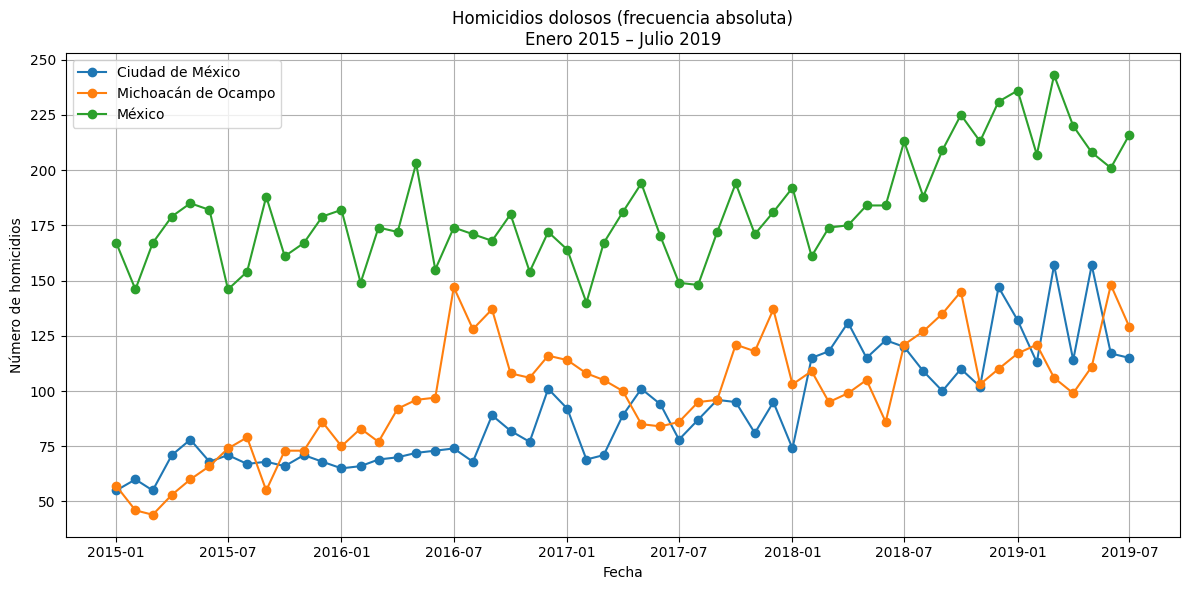

In [18]:
# Graficar la serie temporal
# crear la figura
plt.figure(figsize=(12,6))

# bucle para graficar cada entidad
for entidad in serie['entidad'].unique():
    data = serie[serie['entidad'] == entidad]
    plt.plot(data['fecha'], data['total_delitos'], label=entidad, marker='o')

# Añadir títulos y etiquetas
plt.title('Homicidios dolosos (frecuencia absoluta)\nEnero 2015 – Julio 2019')
plt.xlabel('Fecha')
plt.ylabel('Número de homicidios')
# Agregar leyenda
plt.legend()
# Agregar cuadrícula
plt.grid(True)
# Agregar ajuste de diseño
plt.tight_layout()
# Mostrar la gráfica
plt.show()


#### Ejercicio 2: Contesta las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminicidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [19]:
# Calcular el total de homicidios dolosos en Colima durante 2018
homicidios_colima_2018 = df_largo[
    (df_largo['ano'] == 2018) &
    (df_largo['entidad'] == 'Colima') &
    (df_largo['subtipo_de_delito'].str.lower() == 'homicidio doloso')
]['total_delitos'].sum().astype(int)

print("El total de homicidios dolosos en Colima durante 2018 es:", "\n", homicidios_colima_2018)

El total de homicidios dolosos en Colima durante 2018 es: 
 617


In [20]:
robos_vehiculo_2019 = df_largo[
    (df_largo['ano'] == 2019) &
    (df_largo['subtipo_de_delito'].str.lower() == 'robo de vehículo automotor')
]['total_delitos'].sum().astype(int)

print("En 2019 los delitos reportados por robo de vehículo automotor fueron:", "\n", robos_vehiculo_2019)

En 2019 los delitos reportados por robo de vehículo automotor fueron: 
 187661


In [21]:
violencia_letal_anual = (
    df_largo[
        (
            (df_largo['subtipo_de_delito'].str.lower() == 'homicidio doloso')
        ) |
        (df_largo['tipo_de_delito'].str.lower() == 'feminicidio')
    ]
    .groupby('ano')['total_delitos']
    .sum()
    .reset_index()
    .sort_values('ano')
    .astype({'total_delitos': int})
)

violencia_letal_anual


,ano,total_delitos
0,2015,16532
1,2016,20756
2,2017,25777
3,2018,29995
4,2019,30445
5,2020,29786
6,2021,29263
7,2022,27240
8,2023,26119
9,2024,13255



##### 4. ¿En qué mes y en qué municipio ocurrió el mayor número de feminicidios?
Aclaración importante
El DataFrame actual no contiene la columna "municipio"; sólo dispone de "entidad" (nivel estatal). Por ello, en este ejercicio se utilizará la columna "entidad" para identificar la entidad y el mes con mayor número de feminicidios.

Procedimiento recomendado

Filtrar registros correspondientes a feminicidio " tipo_de_delito".
Agrupar por entidad y mes para sumar total_delitos.
Ordenar de forma descendente y seleccionar la primera fila para obtener la entidad y el mes con el máximo.
Nota sobre análisis a nivel municipal
Para analizar a nivel municipio es necesario contar con datos desagregados por municipio. Puede obtenerse la información municipal descargando los datos desde el portal oficial (https://www.gob.mx/sesnsp/acciones-y-programas/datos-abiertos-de-incidencia-delictiva) o mediante web scraping.



In [22]:
feminicidio_max_mes = (
    df_largo[
        df_largo['tipo_de_delito'] == 'Feminicidio'
    ]
    .groupby(['ano','mes', 'entidad'])['total_delitos']
    .sum()
    .reset_index()
    .sort_values('total_delitos', ascending=False)
    .head(1)
)

# extraer los valores de año, mes y entidad
ano = feminicidio_max_mes.iloc[0]['ano']
mes = feminicidio_max_mes.iloc[0]['mes']
entidad = feminicidio_max_mes.iloc[0]['entidad']

# Imprimir el resultado
print(f"""
El mes con el mayor número de feminicidios registrados fue:
- Mes: {mes}
- Entidad: {entidad}
- Año: {ano}
""")



El mes con el mayor número de feminicidios registrados fue:
- Mes: octubre
- Entidad: México
- Año: 2022



In [23]:
# Calcular el año con el mayor número de feminicidios registrados por estado
feminicidio_max_estado = (
    df_largo[
        df_largo['tipo_de_delito'].str.lower() == 'feminicidio'
    ]
    .groupby(['ano', 'entidad'])['total_delitos']
    .sum()
    .reset_index()
    .sort_values('total_delitos', ascending=False)
    .head(1)
)
# extraer los valores de año y entidad
ano = feminicidio_max_estado.iloc[0]['ano']
estado = feminicidio_max_estado.iloc[0]['entidad']
delitos = feminicidio_max_estado.iloc[0]['total_delitos']

# imprimir el resultado
print(f"""
El año con el mayor número de feminicidios registrados fue:
- Año: {ano}
- Entidad: {estado}
- Total de delitos: {delitos.astype(int)}
""")


El año con el mayor número de feminicidios registrados fue:
- Año: 2020
- Entidad: México
- Total de delitos: 151



#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

In [24]:
# Calcular el total de delitos por año y tipo de delito
delitos_por_ano = (
    df_largo
    .groupby(['ano', 'tipo_de_delito'])['total_delitos']
    .sum()
    .reset_index()
)

# obtener los años únicos
anios = sorted(delitos_por_ano['ano'].unique())


C:\Users\jgesq\AppData\Local\Temp\ipykernel_18904\1957059642.py:24: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


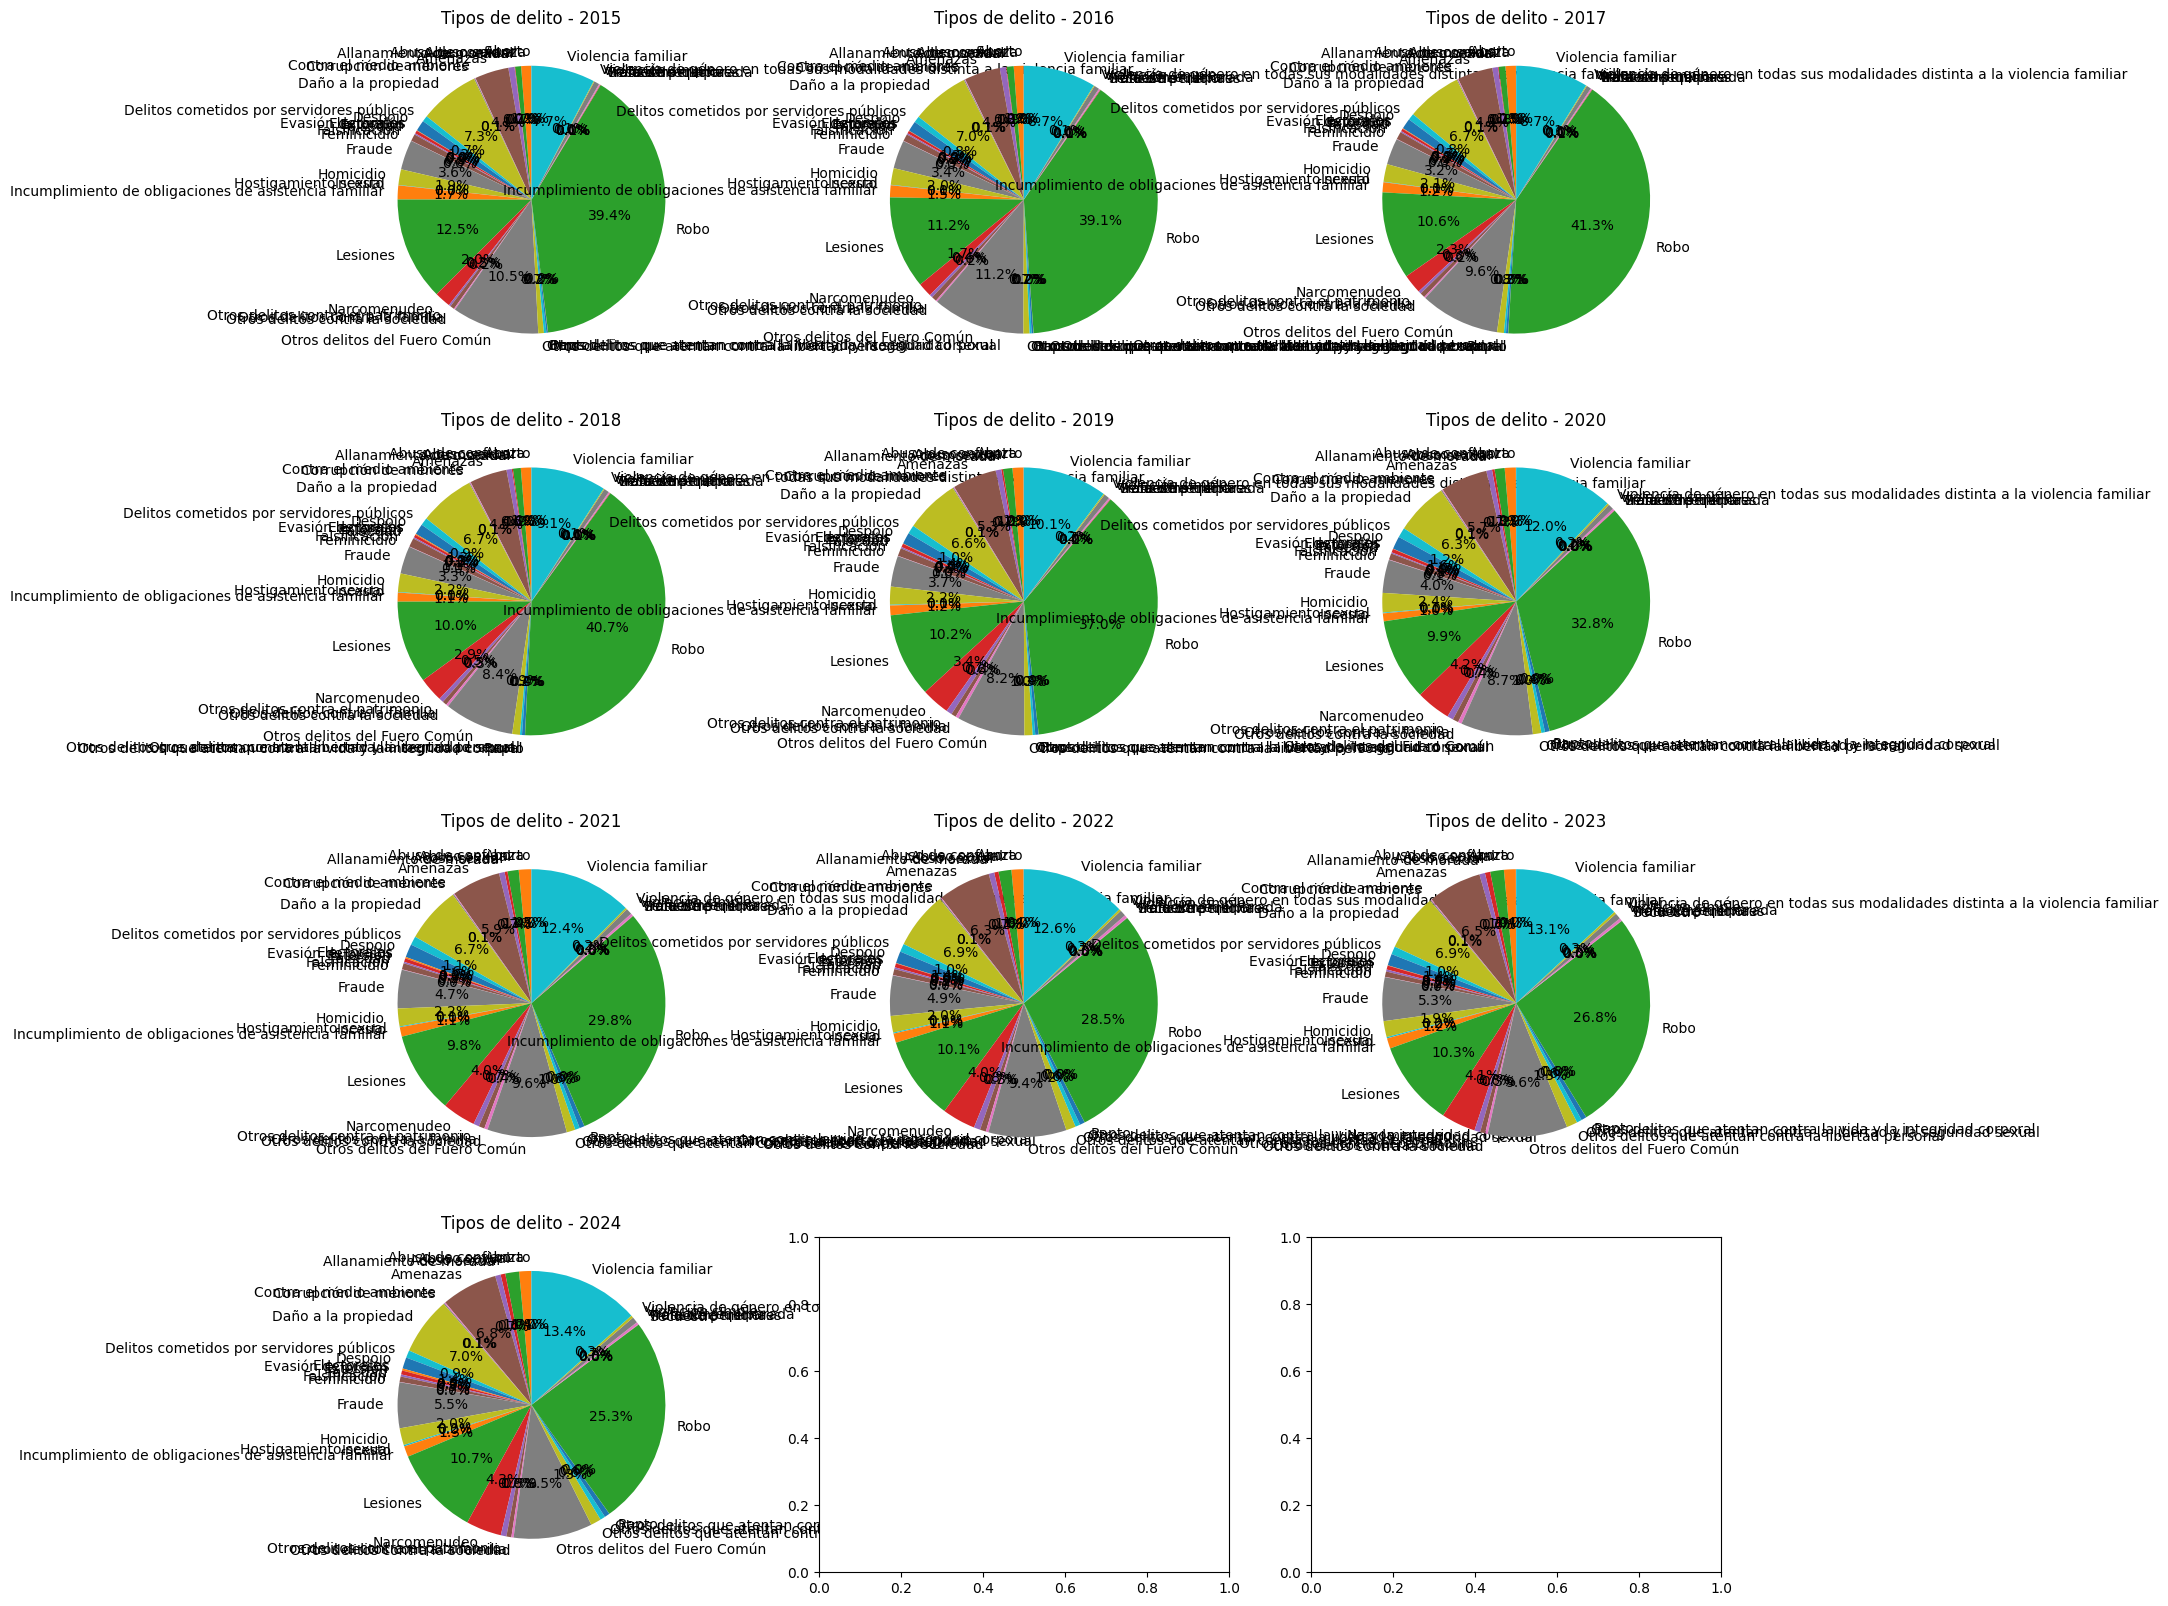

In [25]:
# importar libreria matematica para graficar
import math

# Configurar la cuadrícula de gráficos
n_anios = len(anios)
n_cols = 3
n_rows = math.ceil(n_anios / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
# Graficar los gráficos de pastel para cada año
for i, ano in enumerate(anios):
    data_ano = delitos_por_ano[delitos_por_ano['ano'] == ano]

    axes[i].pie(
        data_ano['total_delitos'],
        labels=data_ano['tipo_de_delito'],
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(f'Tipos de delito - {ano}')
    
plt.tight_layout()
plt.show()
    


Debido a que el número de categorías de delito es elevado, las gráficas de pastel resultan poco legibles y difíciles de interpretar. 
Para mejorar la claridad y facilitar el análisis, se selecciona un **Top N** de los tipos de delito con mayor frecuencia en cada año, 
agrupando el resto de las categorías en una sola clase denominada **“Otros”**. 

Este enfoque permite una visualización más clara y concisa de la distribución relativa de los delitos, 
facilitando la comparación entre años y la identificación de los delitos predominantes.

In [26]:
# Función para preparar los datos para el gráfico de pastel por año
def preparar_pastel_por_ano(df, ano, top_n=5):
    data = (
        df[df['ano'] == ano]
        .groupby('tipo_de_delito')['total_delitos']
        .sum()
        .sort_values(ascending=False)
    )
    
    top = data.head(top_n)
    otros = data.iloc[top_n:].sum()
    
    resultado = top.copy()
    resultado['Otros'] = otros
    
    return resultado


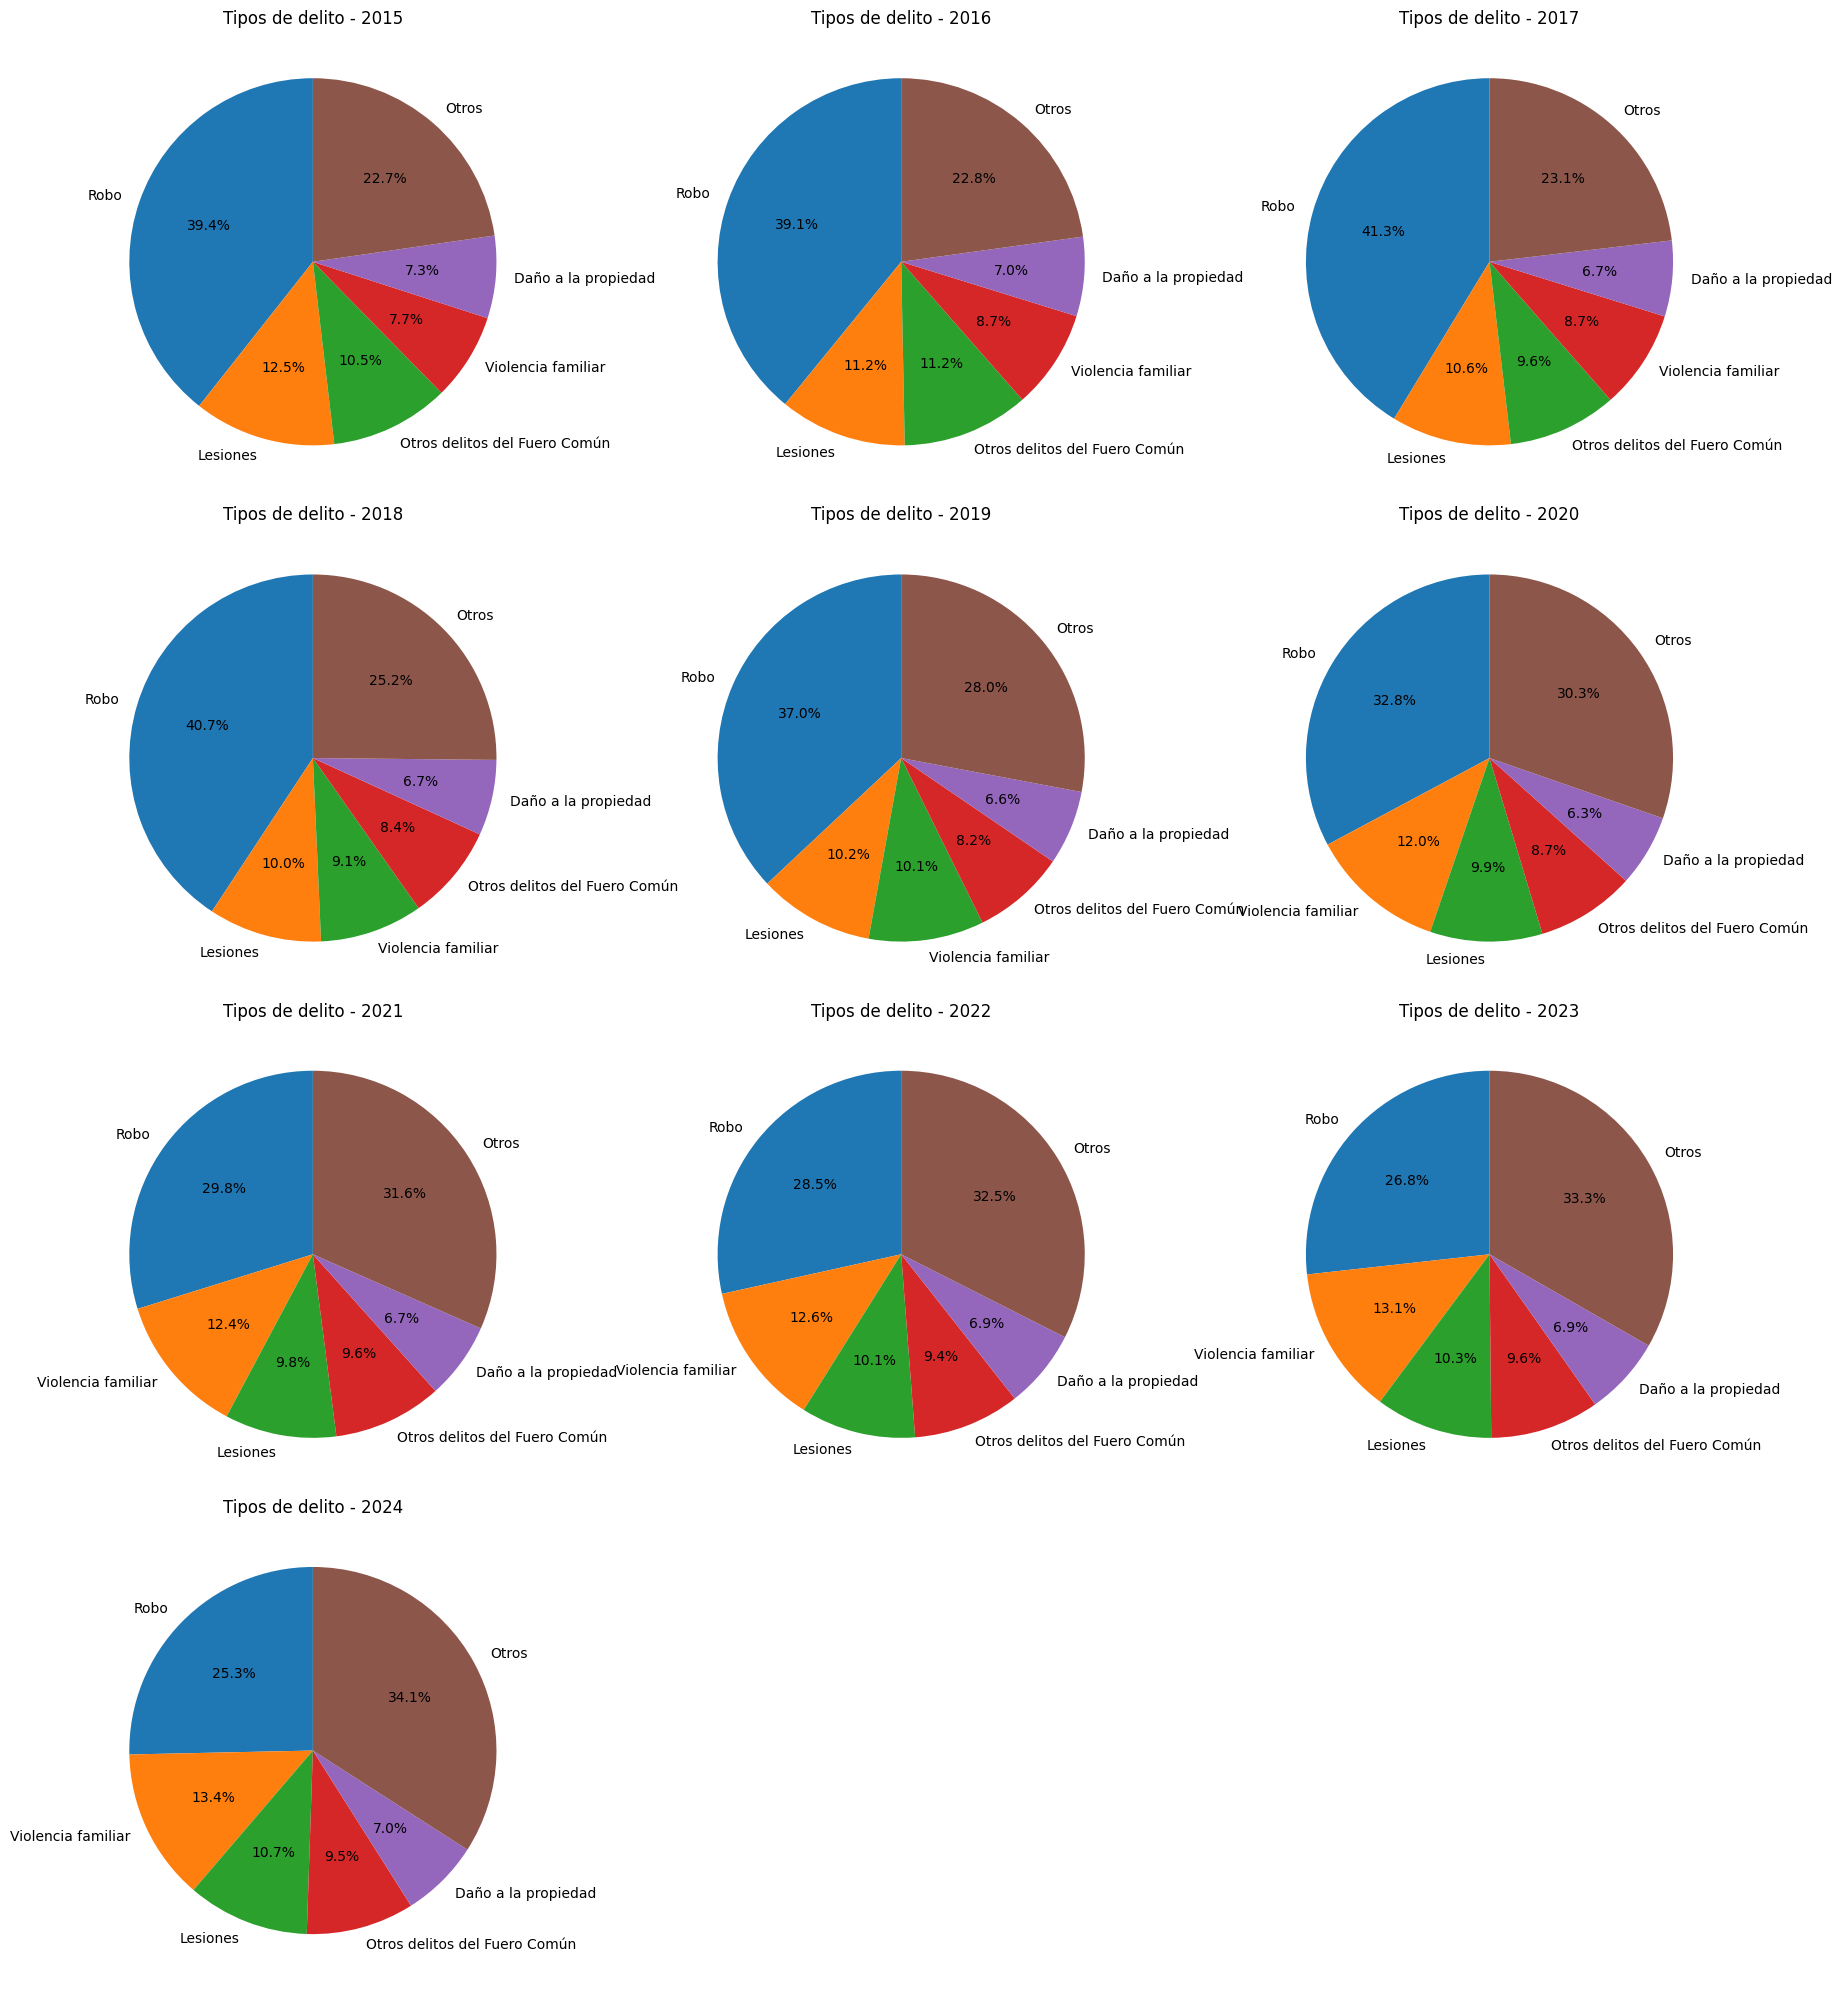

In [27]:
# obtener los años únicos
anios = sorted(df_largo['ano'].unique())

# Configurar la cuadrícula de gráficos
n_cols = 3
n_rows = math.ceil(len(anios) / n_cols)
# Graficar los gráficos de pastel para cada año
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Graficar los gráficos de pastel para cada año
for i, ano in enumerate(anios):
    data_pie = preparar_pastel_por_ano(df_largo, ano)

    axes[i].pie(
        data_pie.values,
        labels=data_pie.index,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(f'Tipos de delito - {ano}')

# eliminar subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ajustar el diseño y mostrar la gráfica
plt.tight_layout()
plt.show()


---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [28]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [29]:
# calcular el total de delitos anuales por entidad 
delitos_anuales = (
    df_largo
    .groupby(['ano', 'clave_ent', 'entidad'])['total_delitos']
    .sum()
    .reset_index()
)

delitos_anuales

,ano,clave_ent,entidad,total_delitos
0,2015,1,Aguascalientes,23212.0
1,2015,2,Baja California,119944.0
2,2015,3,Baja California Sur,21415.0
3,2015,4,Campeche,1886.0
4,2015,5,Coahuila de Zaragoza,46569.0
...,...,...,...,...
315,2024,28,Tamaulipas,20534.0
316,2024,29,Tlaxcala,1693.0
317,2024,30,Veracruz de Ignacio de la Llave,43717.0
318,2024,31,Yucatán,2134.0


In [30]:
pobs.columns

Index(['clave_entidad', 'entidad', 'poblacion'], dtype='object')

In [31]:
delitos_anuales.columns
delitos_anuales = delitos_anuales.rename(columns={
    'clave_ent': 'clave_entidad'
})

In [32]:
# crear el DataFrame df_tasas uniendo delitos_anuales con pobs 
# las columnas deben tener el mismo nombre para hacer el merge
df_tasas = delitos_anuales.merge(
    pobs,
    on=['clave_entidad', 'entidad'],
    how='left'
)

df_tasas.head()

,ano,clave_entidad,entidad,total_delitos,poblacion
0,2015,1,Aguascalientes,23212.0,1312544.0
1,2015,2,Baja California,119944.0,3315766.0
2,2015,3,Baja California Sur,21415.0,712029.0
3,2015,4,Campeche,1886.0,899931.0
4,2015,5,Coahuila de Zaragoza,46569.0,5217908.0


In [33]:
# calcular la tasa de delitos por cada 100,000 habitantes
df_tasas['tasa_100k'] = ((
    df_tasas['total_delitos'] / df_tasas['poblacion']
) * 100000).round(2)


In [34]:
df_tasas['tasa_anualizada'] = (df_tasas['tasa_100k'] * 12).round(2)
df_tasas

,ano,clave_entidad,entidad,total_delitos,poblacion,tasa_100k,tasa_anualizada
0,2015,1,Aguascalientes,23212.0,1312544.0,1768.47,21221.64
1,2015,2,Baja California,119944.0,3315766.0,3617.38,43408.56
2,2015,3,Baja California Sur,21415.0,712029.0,3007.60,36091.20
3,2015,4,Campeche,1886.0,899931.0,209.57,2514.84
4,2015,5,Coahuila de Zaragoza,46569.0,5217908.0,892.48,10709.76
...,...,...,...,...,...,...,...
315,2024,28,Tamaulipas,20534.0,3441698.0,596.62,7159.44
316,2024,29,Tlaxcala,1693.0,1272847.0,133.01,1596.12
317,2024,30,Veracruz de Ignacio de la Llave,43717.0,8112505.0,538.88,6466.56
318,2024,31,Yucatán,2134.0,2097175.0,101.76,1221.12


### EXTRA! 

Graficaremos las tasas por año para poder identificar la entidad con mayor tasa

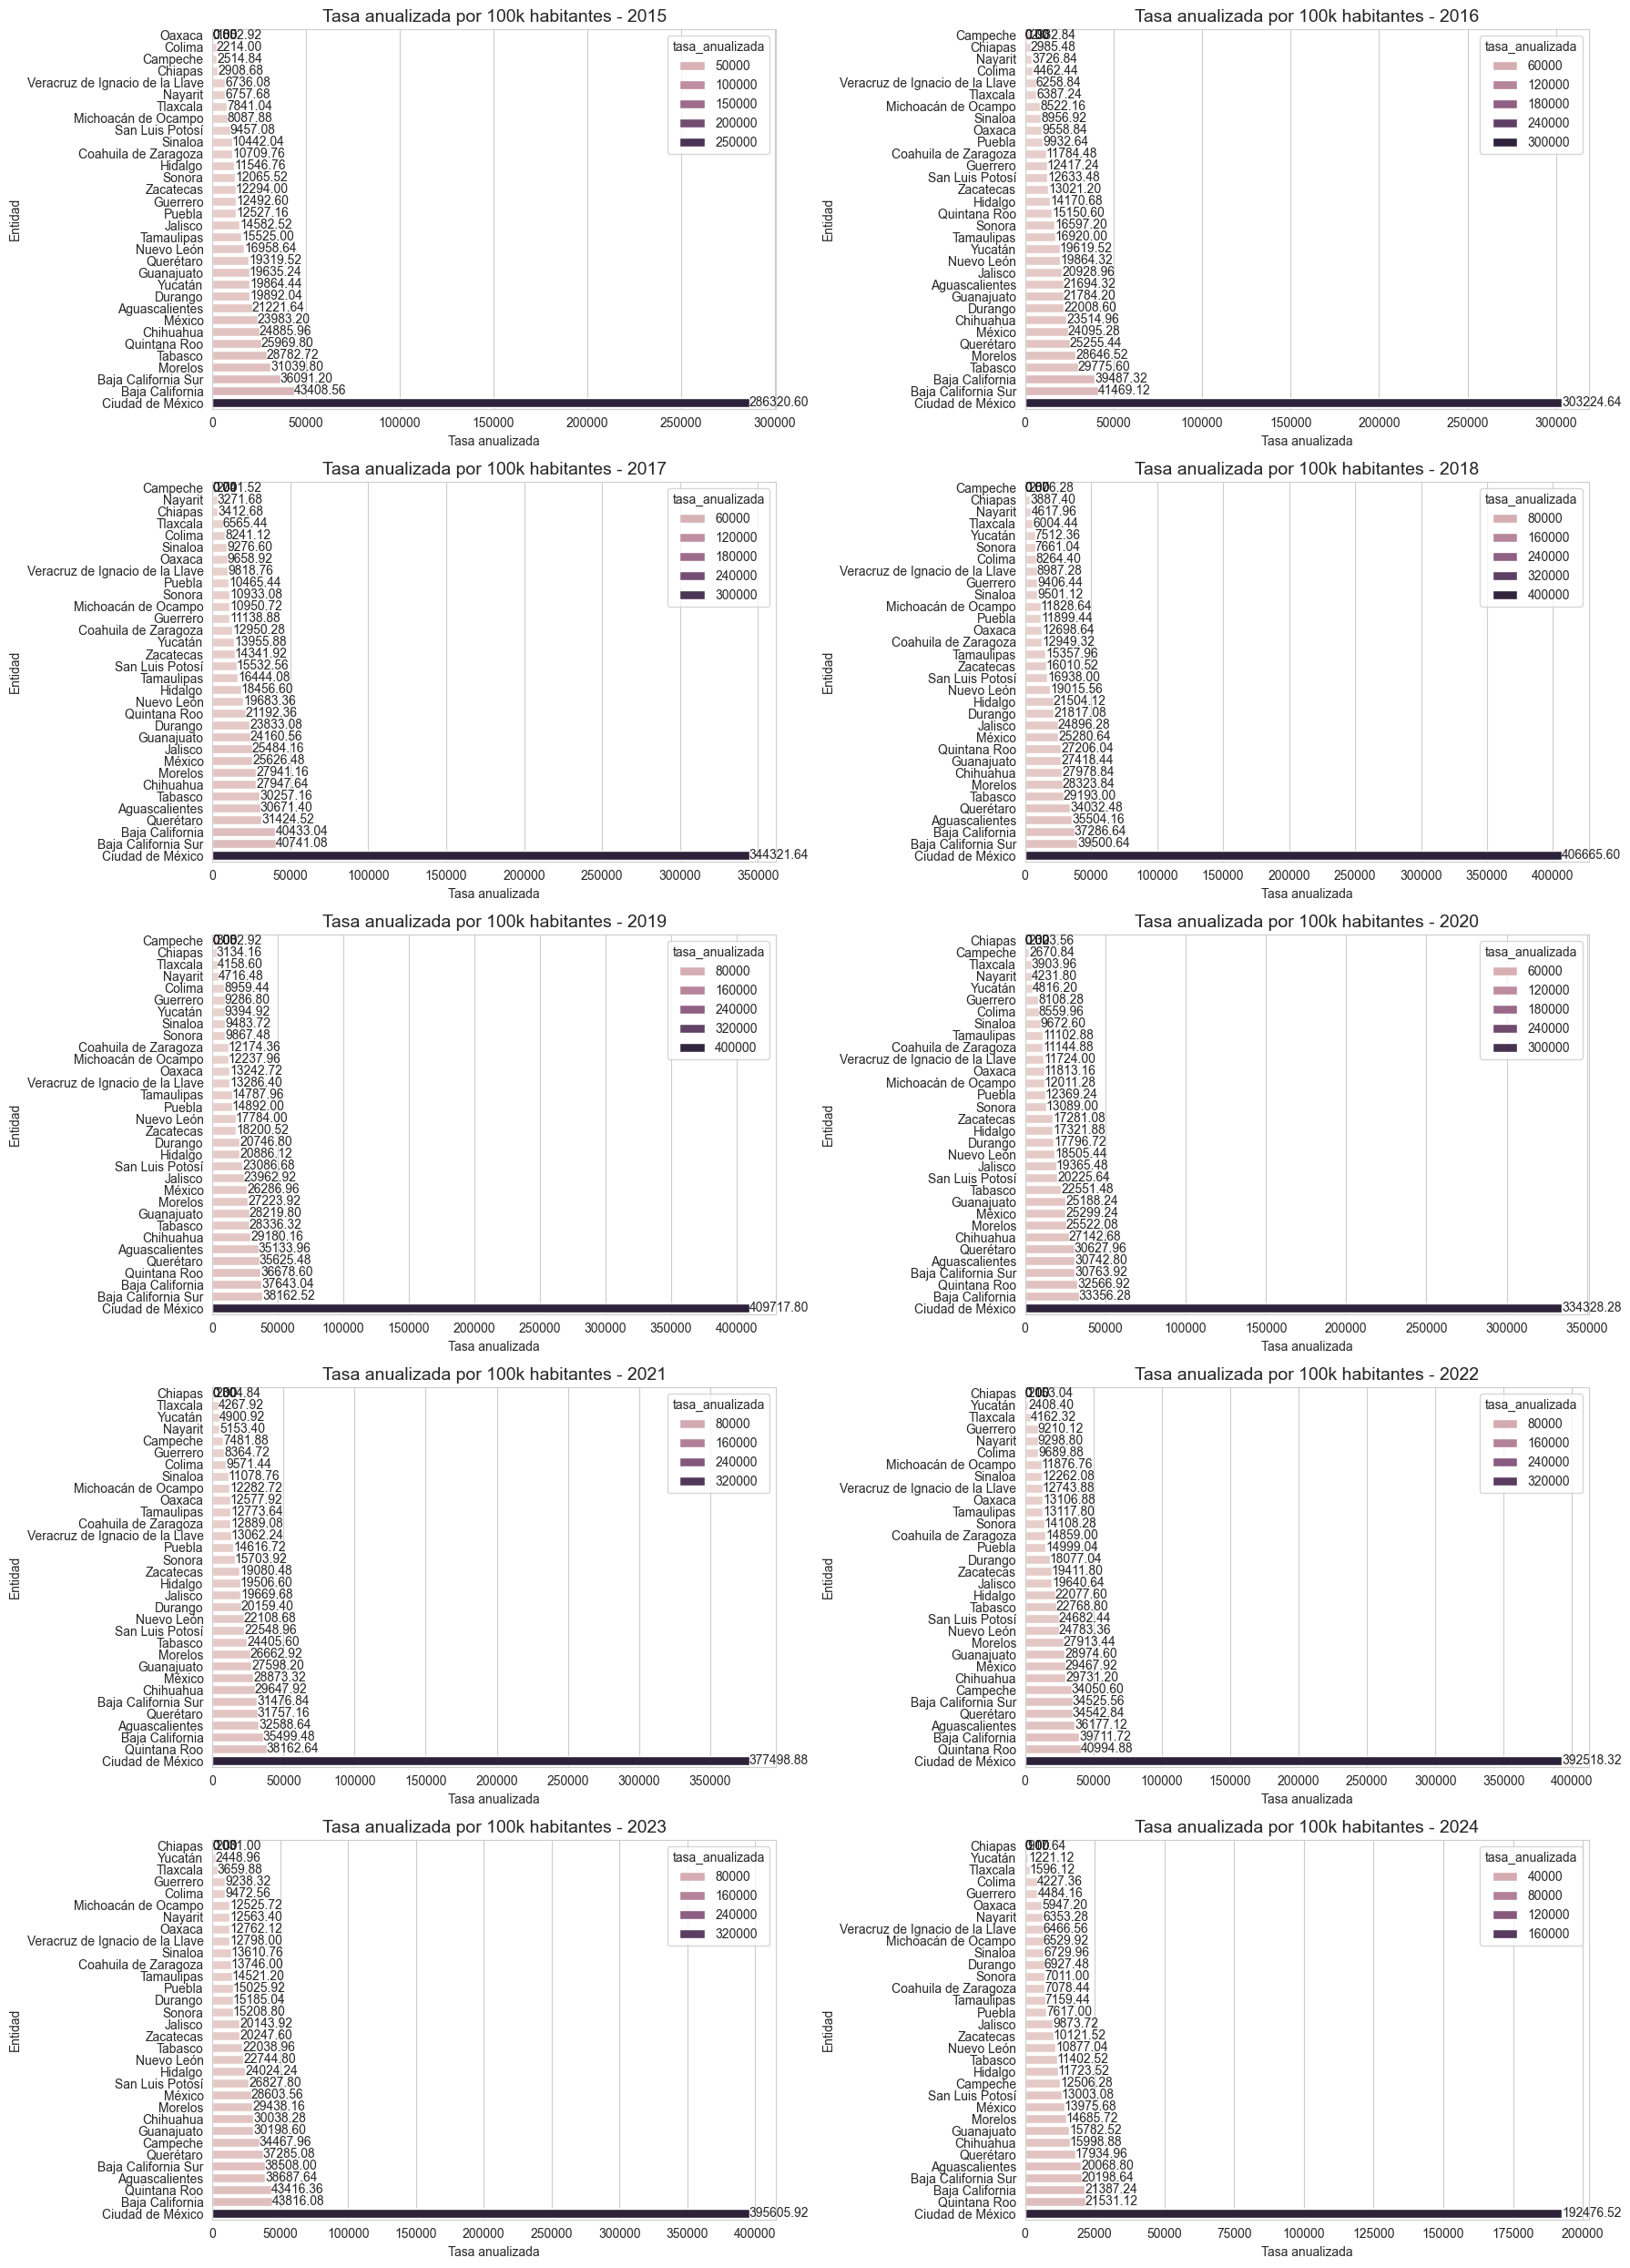

In [35]:
# Importar libreria seaborn para mejores graficos
import seaborn as sns

sns.set_style("whitegrid")

años = sorted(df_tasas['ano'].unique())
n_años = len(años)

cols = 2
rows = (n_años + cols - 1) // cols  # para cubrir todos los años
fig, axes = plt.subplots(rows, cols, figsize=(18, rows*5))
axes = axes.flatten()

for i, año in enumerate(años):
    df_año = df_tasas[df_tasas['ano'] == año].sort_values('tasa_anualizada', ascending=True)
    ax = axes[i]
    
    sns.barplot(
        x='tasa_anualizada',
        y='entidad',
        data=df_año,
        ax=ax,
        hue='tasa_anualizada',
    )
    
    ax.set_title(f'Tasa anualizada por 100k habitantes - {año}', fontsize=14)
    ax.set_xlabel('Tasa anualizada')
    ax.set_ylabel('Entidad')
    
    # Agregar valores encima de las barras
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.5, p.get_y() + p.get_height()/2, f'{width:.2f}', va='center')

# Eliminar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

